In [1]:
import subprocess
import os
import pandas as pd
import netCDF4
import numpy as np
import glob
import time
import matplotlib.pyplot as plt
import copy
import xarray as xr
from datetime import datetime, timedelta 
import dask
from scipy.interpolate import griddata
#from ocean_c_lab_tools import *
#from celluloid import Camera 
#import PyCO2SYS as csys
import seawater as sw
from roms_regrid import *

/tmp/ipykernel_1149602/3005166470.py:17: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
#HAFRO_path='/home/x-uheede/R/HAFRO/Hafro_cruises.xls'
model_grid_path="/home/x-uheede/S/Iceland3_MARBL_2024_60m/P_INPUT/Iceland3_grid_MAT.nc"
# Grid parameters, only modify these if grid is made in MATLAB
vert_levels=60
theta_s_model=5
theta_b_model=2
hc_model=300
model_bgc_dia_path="/home/x-uheede/S/Iceland3_MARBL_2024_60m_CDR/Iceland3_MARBL_2024_bgc_dia.2024022[0-4]??????.nc"
model_bgc_path="/home/x-uheede/S/Iceland3_MARBL_2024_60m_CDR/Iceland3_MARBL_2024_bgc.2024022[0-4]??????.nc"

target_depth_levels=[1,2,3,4,5,7,9,10,12,14,15,16,18,20,26,30,36,40,50,80] # Specify depth levels of interest
thinner=1 # specify the temporal frequency of data being read (i.e. no need to read in hourly data)


In [3]:
from roms_tools import Grid, ROMSOutput

In [4]:
grid = Grid.from_file(
    model_grid_path
)

2025-12-16 17:38:08 - WARNING - Vertical coordinates (Cs_r, Cs_w) not found in grid file.
2025-12-16 17:38:08 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 5.0, theta_b = 2.0, hc = 300.0 ===
2025-12-16 17:38:08 - INFO - Total time: 0.004 seconds
2025-12-16 17:38:08 - INFO - ================================================================================================


In [5]:
#Only run this cell if grid is made in MATLAB
grid.update_vertical_coordinate(N=vert_levels, theta_s=theta_s_model, theta_b=theta_b_model, hc=hc_model, verbose=False)

In [6]:
import xarray as xr
import numpy as np

# Load ROMS output using your pattern
roms_output = ROMSOutput(
    grid=grid,
    path=[
        model_bgc_dia_path,
    ],
    use_dask=True,
)

ds = roms_output.regrid(depth_levels=target_depth_levels)


In [7]:
ds

<xarray.Dataset> Size: 41GB
Dimensions:           (time: 120, lat: 965, lon: 1929, depth: 20)
Coordinates:
  * time              (time) datetime64[ns] 960B 2024-02-20T02:00:00 ... 2024...
  * lat               (lat) float32 4kB 64.0 64.0 64.0 64.0 ... 65.0 65.0 65.0
  * lon               (lon) float32 8kB 337.0 337.0 337.0 ... 339.0 339.0 339.0
  * depth             (depth) float32 80B 1.0 2.0 3.0 4.0 ... 40.0 50.0 80.0
Data variables:
    pCO2SURF          (time, lat, lon) float32 894MB dask.array<chunksize=(1, 965, 1929), meta=np.ndarray>
    FG_CO2            (time, lat, lon) float32 894MB dask.array<chunksize=(1, 965, 1929), meta=np.ndarray>
    PH                (time, lat, lon) float32 894MB dask.array<chunksize=(1, 965, 1929), meta=np.ndarray>
    pCO2SURF_ALT_CO2  (time, lat, lon) float32 894MB dask.array<chunksize=(1, 965, 1929), meta=np.ndarray>
    FG_ALT_CO2        (time, lat, lon) float32 894MB dask.array<chunksize=(1, 965, 1929), meta=np.ndarray>
    PH_ALT_CO2        (time, lat, lon) float32 894MB dask.array<chunksize=(1, 965, 1929), meta=np.ndarray>
    pH_3D             (time, lat, lon, depth) float32 18GB dask.array<chunksize=(1, 528, 528, 20), meta=np.ndarray>
    pH_3D_ALT_CO2     (time, lat, lon, depth) float32 18GB dask.array<chunksize=(1, 528, 528, 20), meta=np.ndarray>
Attributes: (12/44)
    global_x:           640
    global_y:           384
    title:              Iceland3_MARBL_2024 , 50 m  resolution
    grid_file:          /anvil/scratch/x-uheede/Iceland3_MARBL_2024_60m/P_INP...
    forcing_files:       /anvil/scratch/x-uheede/Iceland3_MARBL_2024_60m/P_IN...
    forcing_info:       
    ...                 ...
    tide_options:       # of constituents:10 , real , tidalpotential
    river_frc_options:  OFF
    pipe_frc_options:   OFF
    particle_options:   OFF
    git_version:        
    regrid_method:      bilinear

In [8]:
ds.load()

<xarray.Dataset> Size: 77GB
Dimensions:           (time: 120, lat: 965, lon: 1929, depth: 20)
Coordinates:
  * time              (time) datetime64[ns] 960B 2024-02-20T02:00:00 ... 2024...
  * lat               (lat) float32 4kB 64.0 64.0 64.0 64.0 ... 65.0 65.0 65.0
  * lon               (lon) float32 8kB 337.0 337.0 337.0 ... 339.0 339.0 339.0
  * depth             (depth) float32 80B 1.0 2.0 3.0 4.0 ... 40.0 50.0 80.0
Data variables:
    pCO2SURF          (time, lat, lon) float32 894MB nan nan nan ... nan nan nan
    FG_CO2            (time, lat, lon) float32 894MB nan nan nan ... nan nan nan
    PH                (time, lat, lon) float32 894MB nan nan nan ... nan nan nan
    pCO2SURF_ALT_CO2  (time, lat, lon) float32 894MB nan nan nan ... nan nan nan
    FG_ALT_CO2        (time, lat, lon) float32 894MB nan nan nan ... nan nan nan
    PH_ALT_CO2        (time, lat, lon) float32 894MB nan nan nan ... nan nan nan
    pH_3D             (time, lat, lon, depth) float64 36GB nan nan ... nan nan
    pH_3D_ALT_CO2     (time, lat, lon, depth) float64 36GB nan nan ... nan nan
Attributes: (12/44)
    global_x:           640
    global_y:           384
    title:              Iceland3_MARBL_2024 , 50 m  resolution
    grid_file:          /anvil/scratch/x-uheede/Iceland3_MARBL_2024_60m/P_INP...
    forcing_files:       /anvil/scratch/x-uheede/Iceland3_MARBL_2024_60m/P_IN...
    forcing_info:       
    ...                 ...
    tide_options:       # of constituents:10 , real , tidalpotential
    river_frc_options:  OFF
    pipe_frc_options:   OFF
    particle_options:   OFF
    git_version:        
    regrid_method:      bilinear

In [9]:
# Maximum pH at each grid cell (over time)
ph_max = ds["pH_3D"].max(dim="time", skipna=True).max(dim="depth", skipna=True)
ph_max.name = "PH_max"
ph_max.attrs["long_name"] = "Maximum pH"


In [10]:
# Land mask: 1 = land, 0 = ocean
land_mask = xr.where(np.isnan(ph_max), 1, 0)
land_mask.name = "land_mask"

In [11]:
from pyproj import Geod
import matplotlib.pyplot as plt

def add_scalebar(ax, length_km, location=(0.1, 0.05), linewidth=3):
    """
    Add a scale bar to a Cartopy map.

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxes
        Map axes
    length_km : float
        Length of scale bar in kilometers
    location : tuple
        (x_frac, y_frac) position in axes coordinates
    linewidth : int
        Line width
    """

    geod = Geod(ellps="WGS84")

    # Get current map extent in PlateCarree
    lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())

    # Starting point
    lon_start = lon_min + location[0] * (lon_max - lon_min)
    lat_start = lat_min + location[1] * (lat_max - lat_min)

    # Compute endpoint using geodesic
    lon_end, lat_end, _ = geod.fwd(
        lon_start, lat_start,
        az=90,              # eastward
        dist=length_km * 1000
    )

    # Draw scale bar
    ax.plot(
        [lon_start, lon_end],
        [lat_start, lat_start],
        transform=ccrs.PlateCarree(),
        color="black",
        linewidth=linewidth
    )

    # Label
    ax.text(
        (lon_start + lon_end) / 2,
        lat_start + 0.002,
        f"{length_km} km",
        transform=ccrs.PlateCarree(),
        ha="center",
        va="bottom",
        fontsize=9
    )


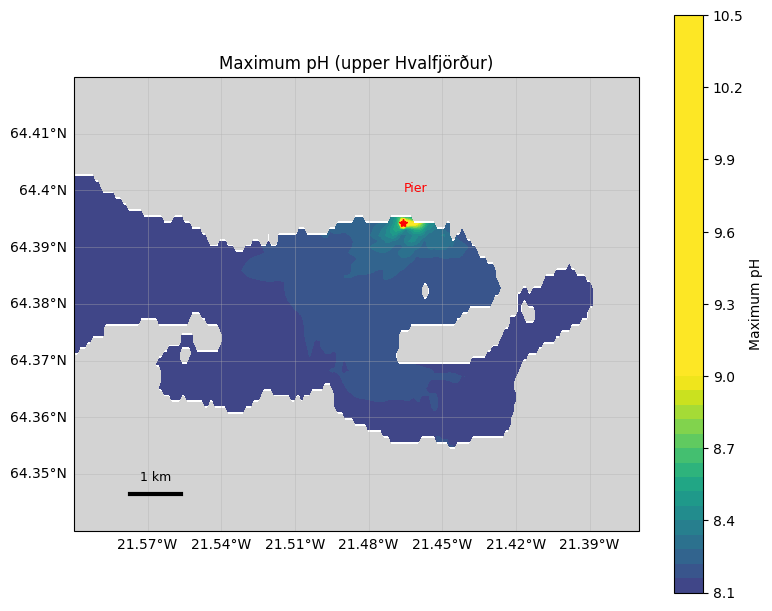

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ph_max_plot = ph_max.assign_coords(
    lon=((ph_max.lon + 180) % 360) - 180
).sortby("lon")

land_mask_plot = land_mask.assign_coords(
    lon=((land_mask.lon + 180) % 360) - 180
).sortby("lon")


extent_upper_hval = [
    -21.6,   # lon min
    -21.37,  # lon max
    64.34,   # lat min
    64.42    # lat max
]
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.Mercator())

ax.set_extent(extent_upper_hval, crs=ccrs.PlateCarree())

# --------------------------------------
# Land mask (plotted FIRST, underneath)
# --------------------------------------
ax.contourf(
    land_mask_plot.lon,
    land_mask_plot.lat,
    land_mask_plot,
    levels=[0.5, 1.5],
    colors=["lightgray"],
    transform=ccrs.PlateCarree(),
    zorder=0
)

# --------------------------------------
# Maximum pH (ocean only)
# --------------------------------------
cf = ax.contourf(
    ph_max_plot.lon,
    ph_max_plot.lat,
    ph_max_plot,
    levels=40, vmin=7.9, vmax=9,
    cmap="viridis",
    transform=ccrs.PlateCarree(),
    zorder=1
)
# Mark Pier
ax.plot(
    -21.465904, 64.394213,
    marker="*", color="red", markersize=6,
    transform=ccrs.PlateCarree()
)
ax.text(
    -21.465904, 64.394213+0.005,
    "Pier",
    color="red",
    fontsize=9,
    transform=ccrs.PlateCarree(),
    ha="left",
    va="bottom"
)


# Gridlines only (no coastlines)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Colorbar
cbar = plt.colorbar(cf, ax=ax, shrink=0.75, pad=0.05)
cbar.set_label("Maximum pH")

ax.set_title("Maximum pH (upper Hvalfjörður)")

add_scalebar(
    ax,
    length_km=1,        # good for upper Hvalfjörður
    location=(0.1, 0.08)
)
plt.tight_layout()
plt.show()



In [23]:
# Maximum pH over the spatial domain for each time step
pH_max_time = ds["pH_3D"].max(dim=("lat", "lon", "depth"), skipna=True)


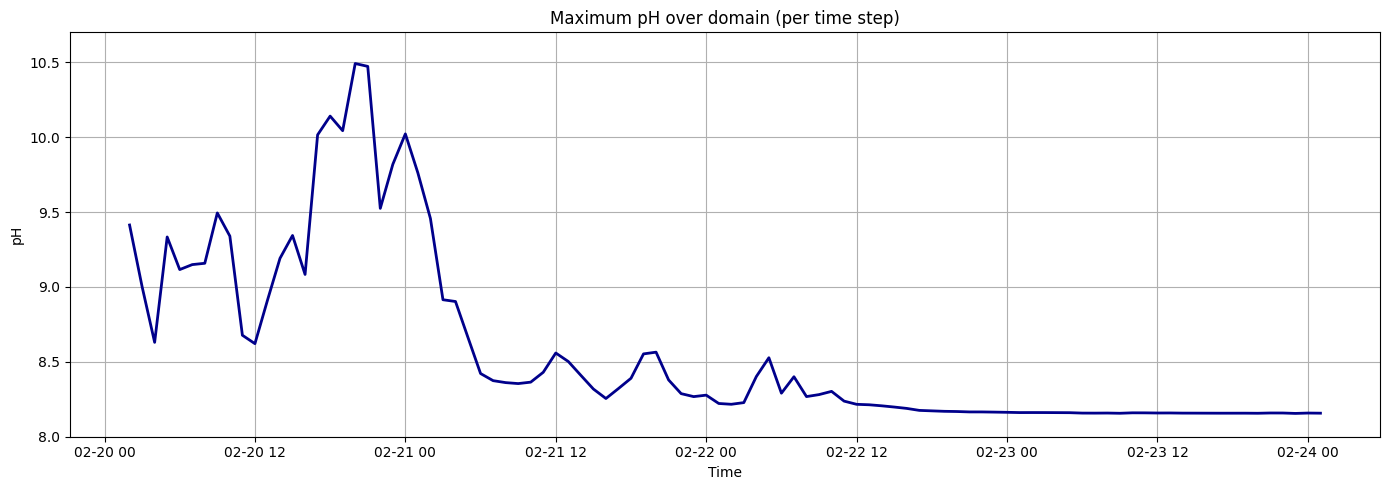

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(
    pH_max_time["time"],
    pH_max_time,
    color="darkblue",
    linewidth=2
)

plt.title("Maximum pH over domain (per time step)")
plt.xlabel("Time")
plt.ylabel("pH")
plt.grid(True)
plt.ylim(8,10.7)
plt.tight_layout()
plt.show()


In [15]:
# Maximum pH at each depth over all time and space
pH_max_profile = ds["pH_3D"].max(
    dim=("time", "lat", "lon"),
    skipna=True
)

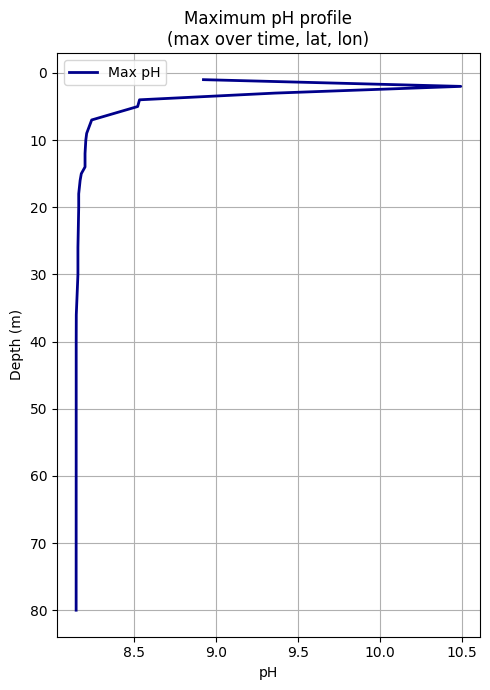

In [16]:
import matplotlib.pyplot as plt

depth = ds["depth"]

plt.figure(figsize=(5, 7))

plt.plot(
    pH_max_profile,
    depth,
    linewidth=2,
    color="darkblue",
    label="Max pH"
)

plt.gca().invert_yaxis()
plt.xlabel("pH")
plt.ylabel("Depth (m)")
plt.title("Maximum pH profile\n(max over time, lat, lon)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [6]:
import xarray as xr
import numpy as np

# Load ROMS output using your pattern
roms_output = ROMSOutput(
    grid=grid,
    path=[
        model_bgc_path,
    ],
    use_dask=True,
)

ds_trac = roms_output.regrid(depth_levels=target_depth_levels, var_names=["ALK", "DIC","ALK_ALT_CO2","DIC_ALT_CO2"])


In [7]:
ds_trac.load()

<xarray.Dataset> Size: 143GB
Dimensions:      (time: 120, lat: 965, lon: 1929, depth: 20)
Coordinates:
  * time         (time) datetime64[ns] 960B 2024-02-20T02:00:00 ... 2024-02-2...
  * lat          (lat) float32 4kB 64.0 64.0 64.0 64.0 ... 65.0 65.0 65.0 65.0
  * lon          (lon) float32 8kB 337.0 337.0 337.0 337.0 ... 339.0 339.0 339.0
  * depth        (depth) float32 80B 1.0 2.0 3.0 4.0 5.0 ... 36.0 40.0 50.0 80.0
Data variables:
    ALK          (time, lat, lon, depth) float64 36GB nan nan nan ... nan nan
    DIC          (time, lat, lon, depth) float64 36GB nan nan nan ... nan nan
    ALK_ALT_CO2  (time, lat, lon, depth) float64 36GB nan nan nan ... nan nan
    DIC_ALT_CO2  (time, lat, lon, depth) float64 36GB nan nan nan ... nan nan
Attributes: (12/44)
    global_x:           640
    global_y:           384
    title:              Iceland3_MARBL_2024 , 50 m  resolution
    grid_file:          /anvil/scratch/x-uheede/Iceland3_MARBL_2024_60m/P_INP...
    forcing_files:       /anvil/scratch/x-uheede/Iceland3_MARBL_2024_60m/P_IN...
    forcing_info:       
    ...                 ...
    tide_options:       # of constituents:10 , real , tidalpotential
    river_frc_options:  OFF
    pipe_frc_options:   OFF
    particle_options:   OFF
    git_version:        
    regrid_method:      bilinear

In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import numpy as np

# Target snapshot
t_snap = np.datetime64("2024-02-21T00:00:00")
depth_target = 2.0

# Select nearest time & depth
ds_snap = ds_trac.sel(
    time=t_snap,
    depth=depth_target,
    method="nearest"
)


In [9]:
ALK_anom = ds_snap["ALK"] - ds_snap["ALK_ALT_CO2"]
DIC_anom = ds_snap["DIC"] - ds_snap["DIC_ALT_CO2"]


/tmp/ipykernel_1149602/4092172213.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


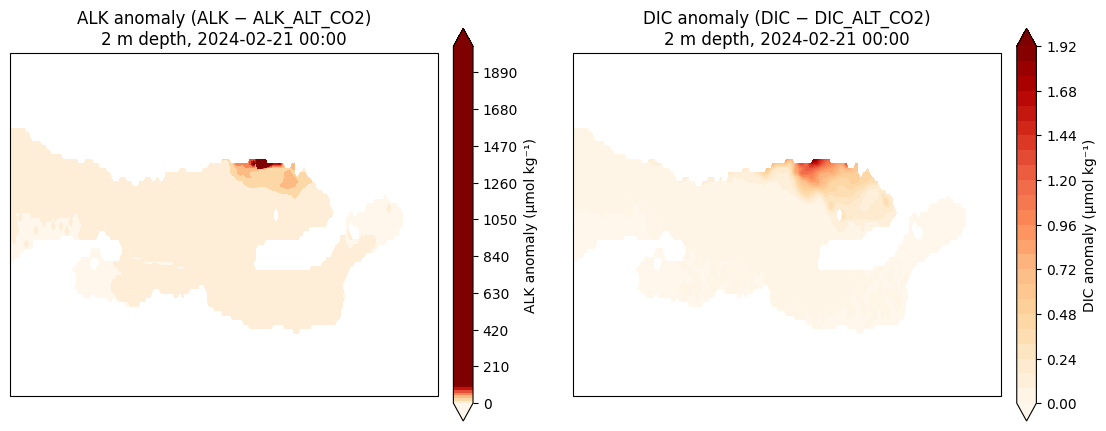

In [25]:
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2, wspace=0.08)

extent_upper_hval = [
    -21.6,   # lon min
    -21.37,  # lon max
    64.34,   # lat min
    64.42    # lat max
]
proj = ccrs.Mercator()
data_crs = ccrs.PlateCarree()

# ==========================
# Panel 1 — ALK anomaly
# ==========================
ax1 = fig.add_subplot(gs[0, 0], projection=proj)
ax1.set_extent(extent_upper_hval, crs=data_crs)

cf1 = ax1.contourf(
    ds_trac["lon"], ds_trac["lat"],
    ALK_anom,
    levels=200,
    cmap="OrRd",vmin=0, vmax=100,
    transform=data_crs,
    extend="both"
)

ax1.set_title("ALK anomaly (ALK − ALK_ALT_CO2)\n2 m depth, 2024-02-21 00:00")
#ax1.set_xticks([-22.2, -22.0, -21.8, -21.6, -21.4], crs=data_crs)
#ax1.set_yticks([64.26, 64.30, 64.34, 64.38, 64.42], crs=data_crs)
ax1.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax1.yaxis.set_major_formatter(cticker.LatitudeFormatter())

cbar1 = fig.colorbar(cf1, ax=ax1, shrink=0.85, pad=0.03)
cbar1.set_label("ALK anomaly (µmol kg⁻¹)")

# ==========================
# Panel 2 — DIC anomaly
# ==========================
ax2 = fig.add_subplot(gs[0, 1], projection=proj)
ax2.set_extent(extent_upper_hval, crs=data_crs)

cf2 = ax2.contourf(
    ds_trac["lon"], ds_trac["lat"],
    DIC_anom,
    levels=31,
    cmap="OrRd", 
    transform=data_crs,
    extend="both"
)

ax2.set_title("DIC anomaly (DIC − DIC_ALT_CO2)\n2 m depth, 2024-02-21 00:00")
#ax2.set_xticks([-22.2, -22.0, -21.8, -21.6, -21.4], crs=data_crs)
#ax2.set_yticks([64.26, 64.30, 64.34, 64.38, 64.42], crs=data_crs)
ax2.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax2.yaxis.set_major_formatter(cticker.LatitudeFormatter())

cbar2 = fig.colorbar(cf2, ax=ax2, shrink=0.85, pad=0.03)
cbar2.set_label("DIC anomaly (µmol kg⁻¹)")

plt.tight_layout()
plt.show()


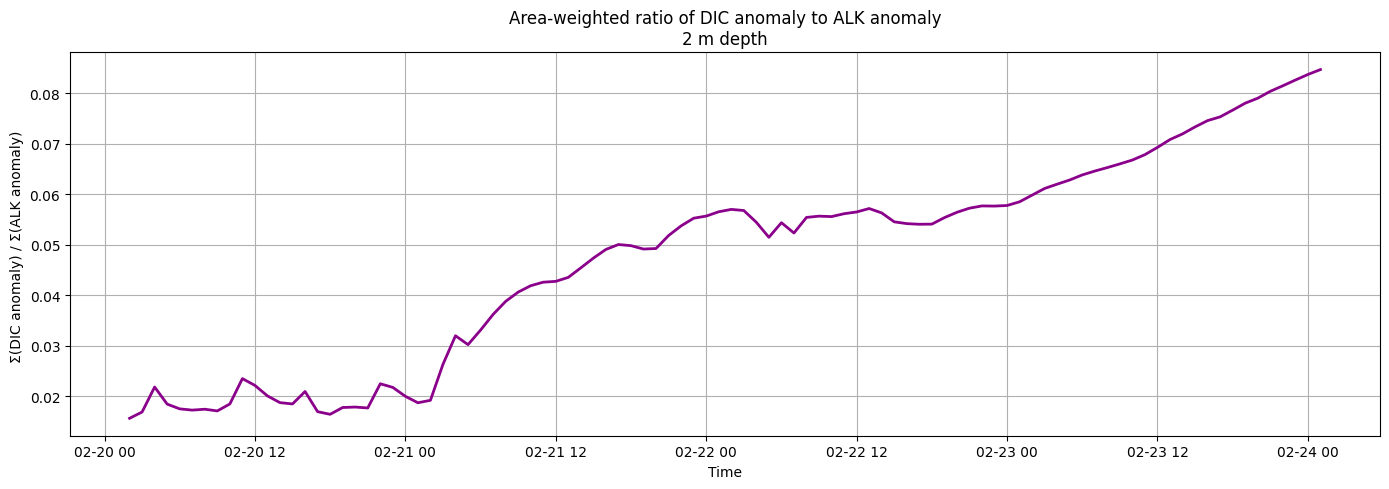

In [29]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# --------------------------------------------------
# User settings
# --------------------------------------------------
depth_target = 2.0   # meters

# --------------------------------------------------
# Select depth
# --------------------------------------------------
ds_2m = ds_trac.sel(depth=depth_target, method="nearest")

# --------------------------------------------------
# Compute anomalies
# --------------------------------------------------
ALK_anom = ds_2m["ALK"] - ds_2m["ALK_ALT_CO2"]
DIC_anom = ds_2m["DIC"] - ds_2m["DIC_ALT_CO2"]

# --------------------------------------------------
# Compute grid-cell area weights (lat/lon grid)
# --------------------------------------------------
R = 6371e3  # Earth radius (m)

lat_rad = np.deg2rad(ds_2m.lat)
lon_rad = np.deg2rad(ds_2m.lon)

dlat = float(np.abs(lat_rad[1] - lat_rad[0]))
dlon = float(np.abs(lon_rad[1] - lon_rad[0]))

cell_area = (
    R**2
    * dlat
    * dlon
    * np.cos(lat_rad)
)

area = xr.DataArray(
    cell_area,
    coords={"lat": ds_2m.lat},
    dims=("lat",)
).broadcast_like(ALK_anom.isel(time=0))

# --------------------------------------------------
# Area-weighted sums
# --------------------------------------------------
ALK_sum = (ALK_anom * area).sum(dim=("lat", "lon"), skipna=True)
DIC_sum = (DIC_anom * area).sum(dim=("lat", "lon"), skipna=True)

# --------------------------------------------------
# Ratio
# --------------------------------------------------
ratio =  DIC_sum / ALK_sum 
ratio = ratio.where(np.isfinite(ratio))

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(14, 5))

plt.plot(
    ratio.time,
    ratio,
    color="darkmagenta",
    linewidth=2,
)

plt.title(
    "Area-weighted ratio of DIC anomaly to ALK anomaly\n"
    "2 m depth"
)
plt.xlabel("Time")
plt.ylabel("Σ(DIC anomaly) / Σ(ALK anomaly) ")
plt.grid(True)

plt.tight_layout()
plt.show()
